# Flagship demo — What a 95% confidence interval really means

*Part 2 · Lesson 12 of 20 · the flagship demo  ·  data: Ames, Iowa housing*

**←** [Lesson 11: Estimation & standard error](11-estimation.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  [Lesson 13: Hypothesis testing: p-values, errors & power](13-hypothesis-testing.ipynb) **→**

**Same idea, another way:**  [Another dataset →](12-confidence-intervals~another-dataset.ipynb)  ·  [The code behind it →](12-confidence-intervals~the-code.ipynb)

Most courses *tell* you about a "95% confidence interval." Here we'll **prove what that 95% means** by simulation.

**The plan (your exact idea):**
1. Take a real dataset and treat the *whole file* as the population — so we actually **know the true mean μ**.
2. Draw a small random sample and build a 95% confidence interval (CI) from it.
3. Do that **100 times** and **count how many of the 100 intervals capture the true mean μ.**
4. Then look at it several different ways.

We use the **Ames, Iowa housing dataset** (2,930 homes). Our variable is **living area (sq ft)** — deliberately *right-skewed*, to show the magic works even when the data is **not** a tidy bell curve.

> **New to notebooks?** The grey boxes below are **code**. Click one and press **Shift + Enter** to run it — the result (a number, a table, or a chart) appears right underneath. Run them **top to bottom**. You do **not** need to understand the first *"Setup"* cell — it just loads the tools and the data, so run it and move on. And you **can't break anything**: re-running a cell is always safe. *(Brand new to all this? The five-minute [Lesson 0 — How these notebooks work](00-how-these-notebooks-work.ipynb) shows you the basics first.)*

In [1]:
import sys, pathlib
for _p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_p / 'lib' / 'statslab.py').exists():
        sys.path.insert(0, str(_p / 'lib')); break
import statslab as sl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
sl.use_course_style()

AMES_URL = 'https://www.openintro.org/data/csv/ames.csv'
ames = sl.load_csv('ames.csv', url=AMES_URL)

population = ames['area'].dropna().to_numpy()    # treat the WHOLE file as the population
MU = population.mean()                            # the TRUE mean (we get to know it!)
SIGMA = population.std(ddof=0)                    # the TRUE population standard deviation
N_POP = len(population)
print(f'Population: {N_POP:,} homes')
print(f'TRUE population mean  MU    = {MU:.1f} sq ft   <- the answer we will try to catch')
print(f'TRUE population stdev SIGMA = {SIGMA:.1f} sq ft')

Population: 2,930 homes
TRUE population mean  MU    = 1499.7 sq ft   <- the answer we will try to catch
TRUE population stdev SIGMA = 505.4 sq ft


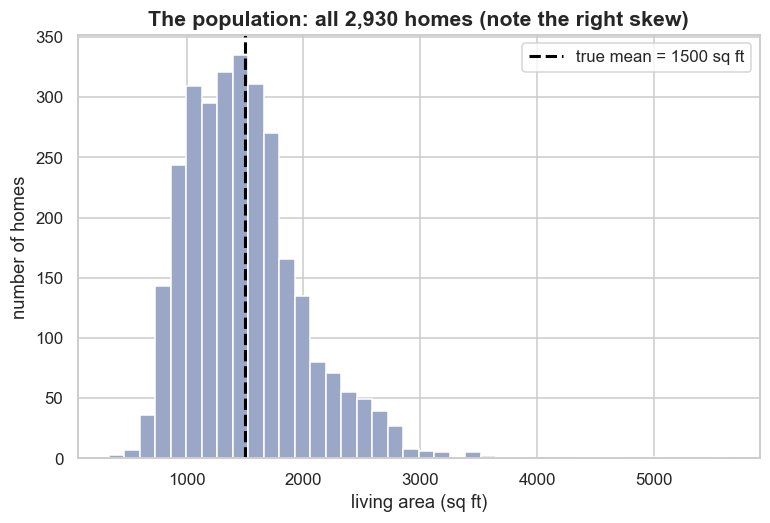

In [2]:
fig, ax = plt.subplots()
ax.hist(population, bins=40, color='#9aa7c7', edgecolor='white')
ax.axvline(MU, color='black', lw=2, ls='--', label=f'true mean = {MU:.0f} sq ft')
ax.set_xlabel('living area (sq ft)'); ax.set_ylabel('number of homes')
ax.set_title('The population: all 2,930 homes (note the right skew)')
ax.legend(); plt.show()

## Step 1 — one sample, one interval

In real life you can't measure everyone — you take a **sample**. From it you estimate the mean, and you report a **confidence interval**: a range that says "the true mean is plausibly in here."

For a mean, the 95% CI is:

$$\bar{x} \;\pm\; t^{*}\cdot \frac{s}{\sqrt{n}}$$

- $\bar{x}$ — the **sample** mean (our estimate of μ).
- $s$ — the sample standard deviation (how spread the sample is).
- $n$ — the sample size. Bigger $n$ → narrower interval (that $\sqrt{n}$).
- $s/\sqrt{n}$ — the **standard error**: how much $\bar{x}$ wobbles from sample to sample.
- $t^{*}$ — a multiplier (about 2 for 95%) from the *t-distribution*, sized so the recipe works 95% of the time.

In [3]:
rng = np.random.default_rng(7)   # change this seed to draw a different sample
n = 50

def confidence_interval(sample, level=0.95):
    n = len(sample)
    xbar = sample.mean()
    s = sample.std(ddof=1)
    se = s / np.sqrt(n)
    tcrit = stats.t.ppf(1 - (1 - level) / 2, df=n - 1)
    return xbar - tcrit * se, xbar + tcrit * se, xbar

sample = rng.choice(population, size=n, replace=False)
lo, hi, xbar = confidence_interval(sample)
print(f'Sample mean  = {xbar:.1f} sq ft')
print(f'95% CI       = ({lo:.1f}, {hi:.1f})')
print(f'True mean MU = {MU:.1f} sq ft')
print('Did THIS interval catch the true mean? ->', 'YES' if lo <= MU <= hi else 'NO')

Sample mean  = 1531.3 sq ft
95% CI       = (1372.8, 1689.7)
True mean MU = 1499.7 sq ft
Did THIS interval catch the true mean? -> YES


## Step 2 — do it 100 times and count

One interval either catches μ or it doesn't — that's luck. The real claim of "95% confidence" is about the **long run**:

> If we repeated the whole process many times, about **95%** of the intervals would contain the true mean.

So let's build **100** intervals and count.

In [4]:
n_intervals = 100
results = []
for _ in range(n_intervals):
    s = rng.choice(population, size=n, replace=False)
    lo, hi, xbar = confidence_interval(s)
    results.append({'lo': lo, 'hi': hi, 'xbar': xbar, 'hit': lo <= MU <= hi})

hits = sum(r['hit'] for r in results)
print(f'{hits} out of {n_intervals} intervals contained the true mean ({MU:.1f} sq ft).')
print(f'That is {hits}% coverage - the theory predicts about 95%.')

95 out of 100 intervals contained the true mean (1499.7 sq ft).
That is 95% coverage - the theory predicts about 95%.


### Picture it — the "caterpillar" plot

Each horizontal line is one sample's 95% CI. **Green** intervals caught the true mean; **red** ones missed. The dashed vertical line is the true mean μ.

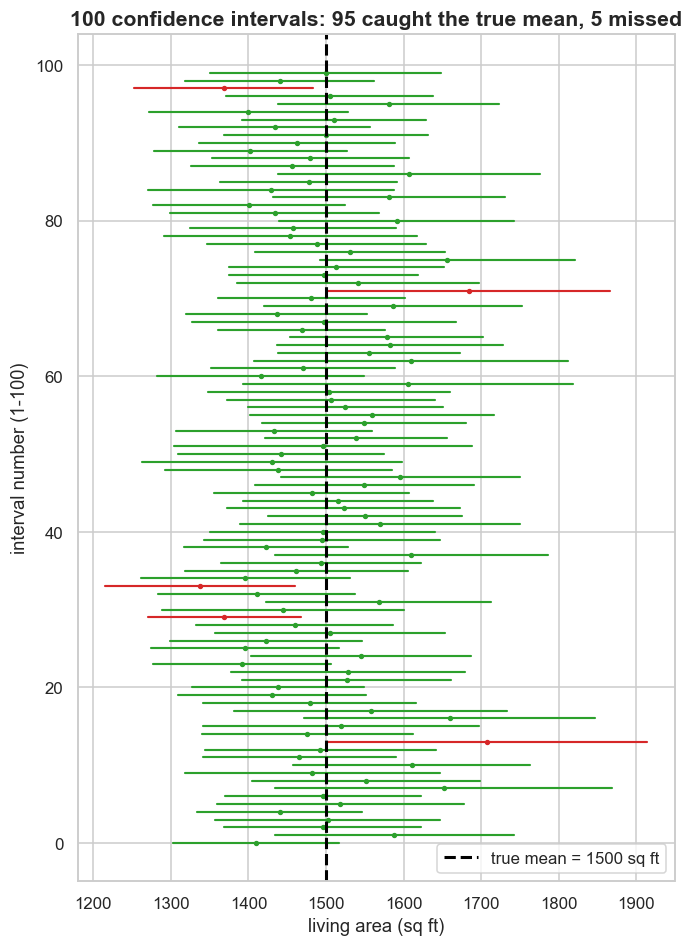

In [5]:
fig, ax = plt.subplots(figsize=(7, 10))
for i, res in enumerate(results):
    color = '#2ca02c' if res['hit'] else '#d62728'
    ax.plot([res['lo'], res['hi']], [i, i], color=color, lw=1.4)
    ax.plot(res['xbar'], i, 'o', color=color, ms=2.5)
ax.axvline(MU, color='black', ls='--', lw=2, label=f'true mean = {MU:.0f} sq ft')
ax.set_xlabel('living area (sq ft)'); ax.set_ylabel('interval number (1-100)')
ax.set_title(f'100 confidence intervals: {hits} caught the true mean, {n_intervals - hits} missed')
ax.legend(loc='lower right'); plt.show()

### What "95% confidence" does — and does *not* — mean

- ✅ **Correct:** *the procedure* catches the true mean about 95% of the time. The confidence is in the **method**, across many repeats.
- ❌ **Wrong:** "there's a 95% probability μ is inside *this particular* interval." Once an interval is computed, μ is either in it or not — the 95% is the long-run hit rate, not a probability about one interval.

The red intervals above are the ~5% that miss. They aren't mistakes — they're the expected price of sampling.

## Step 3 — push it to 10,000 to watch the rate settle

100 intervals landed near 95. With **10,000**, the coverage should sit very close to the promised 95%.

In [6]:
def coverage(level, n=50, trials=10000):
    hits = 0
    for _ in range(trials):
        s = rng.choice(population, size=n, replace=False)
        lo, hi, _ = confidence_interval(s, level=level)
        hits += (lo <= MU <= hi)
    return hits / trials

print(f'Coverage of the 95% method over 10,000 samples: {coverage(0.95) * 100:.1f}%')

Coverage of the 95% method over 10,000 samples: 95.0%


### Higher confidence = a wider net (the trade-off)

Want to be *more* sure of catching μ? Use a higher confidence level — but the interval gets **wider** (less precise). Let's compare 80% / 90% / 95% / 99% on both **coverage** (does it keep its promise?) and **average width**.

level  coverage_%  avg_width_sqft
  80%       80.40      183.537606
  90%       89.52      237.322409
  95%       95.08      283.183501
  99%       98.64      378.336154


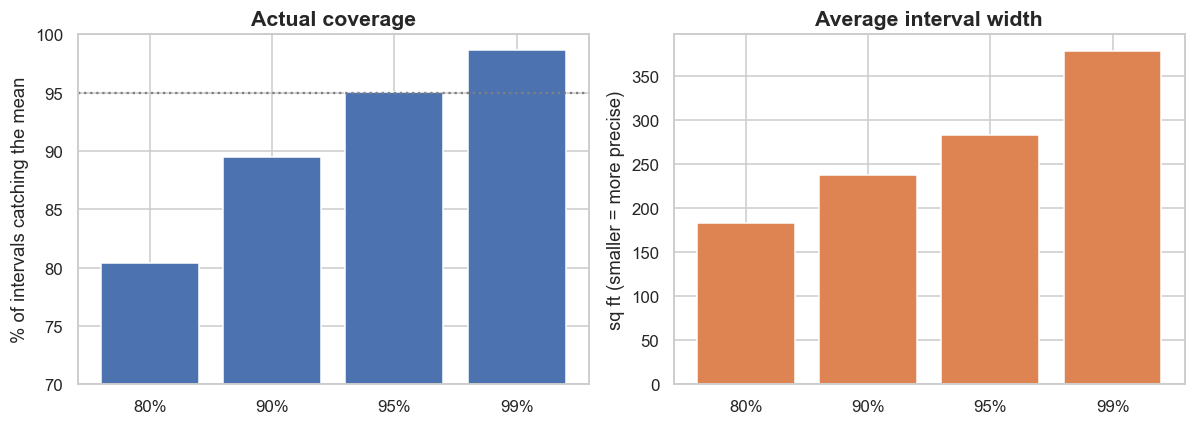

In [7]:
levels = [0.80, 0.90, 0.95, 0.99]
rows = []
for lev in levels:
    widths, hits, trials = [], 0, 5000
    for _ in range(trials):
        s = rng.choice(population, size=50, replace=False)
        lo, hi, _ = confidence_interval(s, level=lev)
        widths.append(hi - lo); hits += (lo <= MU <= hi)
    rows.append({'level': f'{int(lev*100)}%', 'coverage_%': hits / trials * 100, 'avg_width_sqft': np.mean(widths)})
summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.bar(summary['level'], summary['coverage_%'], color='#4c72b0'); a1.axhline(95, color='grey', ls=':')
a1.set_title('Actual coverage'); a1.set_ylabel('% of intervals catching the mean'); a1.set_ylim(70, 100)
a2.bar(summary['level'], summary['avg_width_sqft'], color='#dd8452')
a2.set_title('Average interval width'); a2.set_ylabel('sq ft (smaller = more precise)')
plt.tight_layout(); plt.show()

## Why it works — the engine underneath (the Central Limit Theorem)

Confidence intervals lean on a near-magical fact: even though the population of house sizes is **skewed**, the **sample means** pile up into a tidy **bell curve** centered on μ. That's the **Central Limit Theorem (CLT)**, and its spread is the standard error $\sigma/\sqrt{n}$.

*(Lesson 10 builds this engine from scratch — if you haven't seen it yet, it's worth a detour.)*

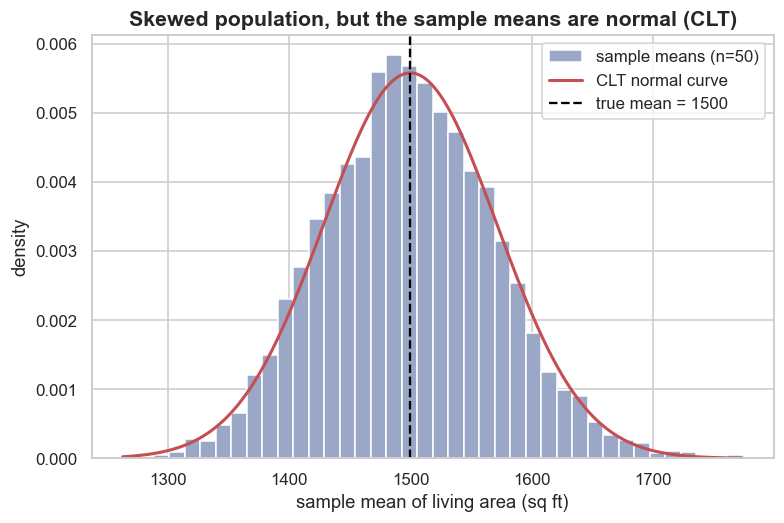

Std of the sample means   = 70.8 sq ft
CLT prediction sigma/sqrt(n) = 71.5 sq ft   (they should match)


In [8]:
many_means = np.array([rng.choice(population, size=50, replace=False).mean() for _ in range(5000)])
fig, ax = plt.subplots()
ax.hist(many_means, bins=40, density=True, color='#9aa7c7', edgecolor='white', label='sample means (n=50)')
xs = np.linspace(many_means.min(), many_means.max(), 200)
ax.plot(xs, stats.norm.pdf(xs, MU, SIGMA / np.sqrt(50)), 'r-', lw=2, label='CLT normal curve')
ax.axvline(MU, color='black', ls='--', label=f'true mean = {MU:.0f}')
ax.set_xlabel('sample mean of living area (sq ft)'); ax.set_ylabel('density')
ax.set_title('Skewed population, but the sample means are normal (CLT)')
ax.legend(); plt.show()
print(f'Std of the sample means   = {many_means.std():.1f} sq ft')
print(f'CLT prediction sigma/sqrt(n) = {SIGMA / np.sqrt(50):.1f} sq ft   (they should match)')

## Now you try

Predict first, then change a number and re-run:

1. **Sample size `n`** — set `n = 15`, then `n = 200`. Wider or narrower intervals? Does coverage stay ~95%?
2. **The seed** — change `np.random.default_rng(7)` to any number for a fresh batch. Roughly how many of 100 still hit?
3. **A different variable** — swap `ames['area']` for `ames['price']` (sale price). The skew is stronger; does the method still cover ~95%?

## Recap — the three levels

- **The math:** $\bar{x} \pm t^{*}\, s/\sqrt{n}$ — an estimate, plus-or-minus a multiplier times the standard error.
- **The meaning:** a CI is a *range of plausible values* for the unknown true mean, built so the **recipe** succeeds about 95% of the time.
- **The interpretation:** "95% confidence" is about the **method's long-run hit rate**, not the probability for one fixed interval. You watched ~95 of 100 succeed — and the ~5 that missed are exactly what theory expects.

---

**← Previous:** [Lesson 11: Estimation & standard error](11-estimation.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Next →:** [Lesson 13: Hypothesis testing: p-values, errors & power](13-hypothesis-testing.ipynb)

**Same idea, another way:**  [Another dataset →](12-confidence-intervals~another-dataset.ipynb)  ·  [The code behind it →](12-confidence-intervals~the-code.ipynb)